In [ ]:
!pip install -q keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import io
import keras_tuner as kt
from google.colab import files
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

In [ ]:
uploaded = files.upload()

Saving Student_performance_data.csv to Student_performance_data.csv


In [ ]:
df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))

In [ ]:
print("First few rows of the dataset:")
df.head()

First few rows of the dataset:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [ ]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


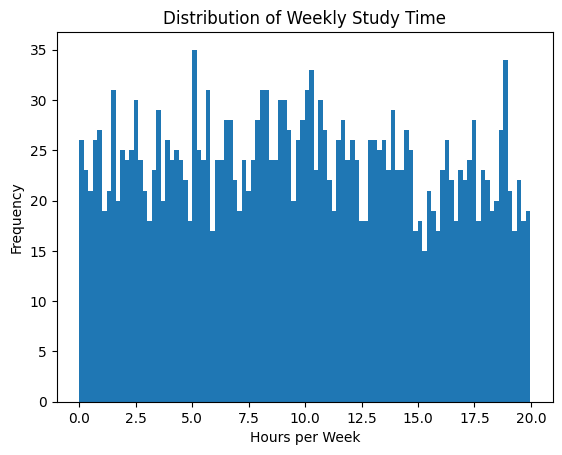

In [ ]:
ax = df['StudyTimeWeekly'].plot(kind='hist', bins=100, title='Distribution of Weekly Study Time')
ax.set_xlabel('Hours per Week')
plt.show()

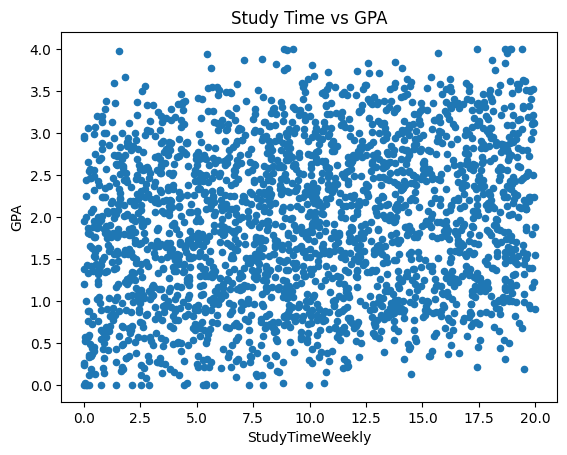

In [ ]:
df.plot(kind='scatter', x='StudyTimeWeekly', y='GPA', title='Study Time vs GPA')
plt.show()

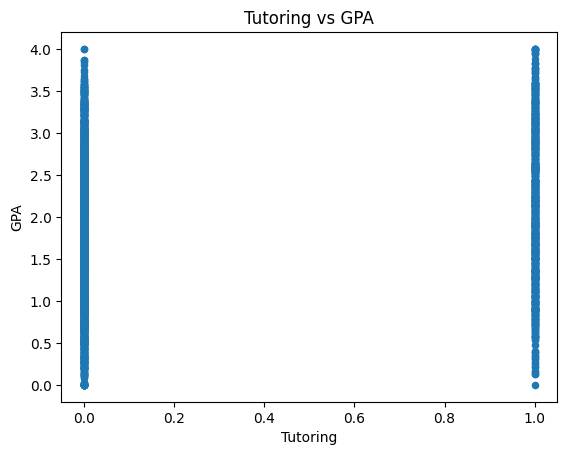

In [ ]:
df.plot(kind='scatter', x='Tutoring', y='GPA', title='Tutoring vs GPA')
plt.show()

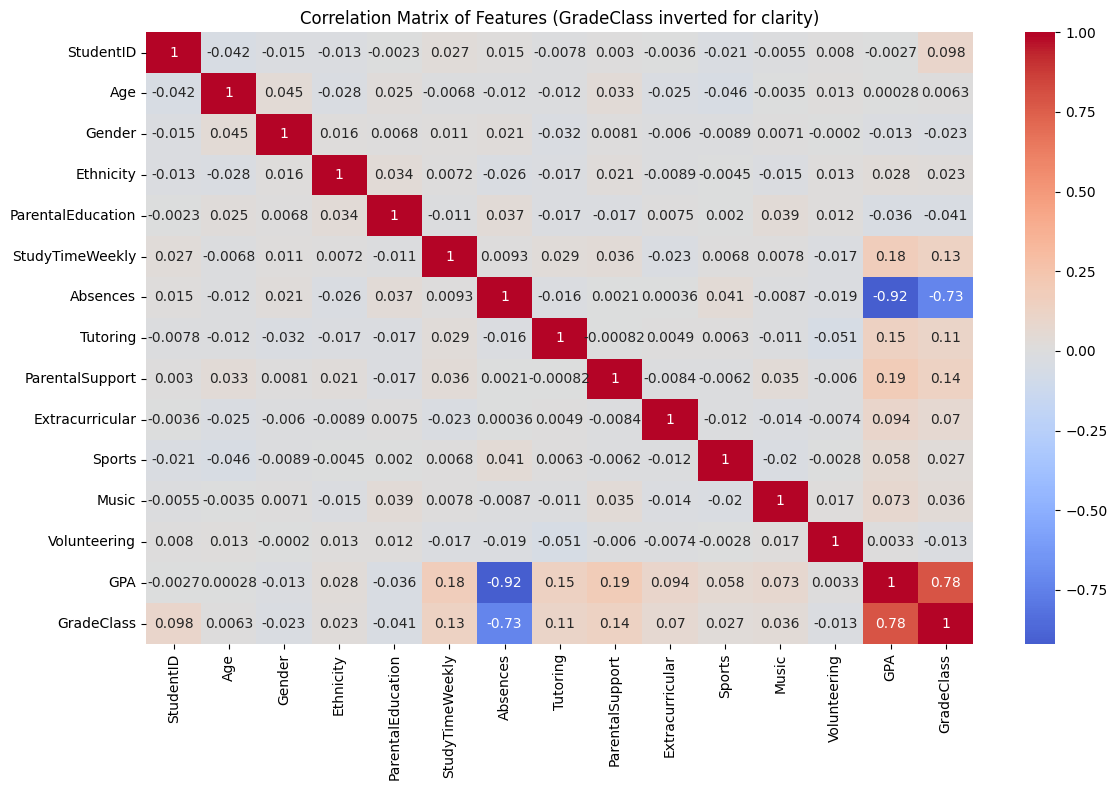

Correlation with GPA:
GPA                  1.000000
GradeClass           0.782835
ParentalSupport      0.190774
StudyTimeWeekly      0.179275
Tutoring             0.145119
Extracurricular      0.094078
Music                0.073318
Sports               0.057859
Ethnicity            0.027760
Volunteering         0.003258
Age                  0.000275
StudentID           -0.002697
Gender              -0.013360
ParentalEducation   -0.035854
Absences            -0.919314
Name: GPA, dtype: float64


In [ ]:
# Correlation matrix
correlation_matrix = df.corr()

# Invert GradeClass correlation for better interpretation
# (since GradeClass is inverse-encoded: 0=A, 4=F)
correlation_matrix.loc['GradeClass'] = correlation_matrix.loc['GradeClass'] * -1
correlation_matrix['GradeClass'] = correlation_matrix['GradeClass'] * -1

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Features (GradeClass inverted for clarity)')
plt.tight_layout()
plt.show()

# See which features correlate most with GPA
print("Correlation with GPA:")
print(correlation_matrix['GPA'].sort_values(ascending=False))

In [ ]:
df = df[
    [
      # 'StudentID', 'Volunteering', 'Age', 'GradeClass'
      'Ethnicity',
      'ParentalEducation', 'Gender',
      'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
      'Extracurricular', 'Sports', 'Music','GPA',
      ]
].copy()

In [ ]:
# start regression model
y = df["GPA"]
X = df.drop("GPA", axis=1)  # Remove GPA from features for regression

In [ ]:
print("Feature shape:", X.shape)


Feature shape: (2392, 10)


In [ ]:
le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = le.fit_transform(X[col])


In [ ]:
feature_names = X.columns.tolist()


In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# SMOTE not needed for regression (it's for classification)
# Use original scaled data
X_resampled = X_scaled
y_resampled = y

In [ ]:
X_resampled_df = pd.DataFrame(X_resampled, columns=feature_names)


In [ ]:
X_seq = X_resampled_df.values


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)


In [ ]:
def build_model(hp):
    model = Sequential()

    model.add(Conv1D(
        filters=hp.Choice("filters", [16, 32, 64]),
        kernel_size=hp.Choice("kernel_size", [2, 3, 5]),
        activation="relu",
        padding="same",
        input_shape=(X_train.shape[1], 1)
    ))

    model.add(MaxPooling1D(
        pool_size=hp.Choice("pool_size", [2, 3])
    ))

    model.add(Bidirectional(GRU(
        units=hp.Choice("gru_units", [16, 32, 64])
    )))

    model.add(Dense(
        units=hp.Choice("dense_units", [32, 64, 128]),
        activation="relu"
    ))

    model.add(Dropout(
        rate=hp.Float("dropout", 0.2, 0.6, step=0.1)
    ))

    model.add(Dense(1, activation="linear"))

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice("lr", [1e-2, 1e-3, 1e-4])
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_mae",
    max_trials=20,
    executions_per_trial=1,
    directory="random_search",
    project_name="cnn_bigru_gpa"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tuner.search(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Trial 20 Complete [00h 00m 12s]
val_mae: 0.19012057781219482

Best val_mae So Far: 0.18061453104019165
Total elapsed time: 00h 04m 11s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
y_pred = best_model.predict(X_test).flatten()
y_test_values = np.array(y_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test_values, y_pred)
mae = mean_absolute_error(y_test_values, y_pred)
r2  = r2_score(y_test_values, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)


Mean Squared Error: 0.05444093020035232
Mean Absolute Error: 0.18437400214454205
R² Score: 0.9341652157907467


In [ ]:
print("\nSample predictions vs actual GPA:")
for i in range(10):
    print(f"Predicted: {y_pred[i]:.2f}, Actual: {y_test_values[i]:.2f}")



Sample predictions vs actual GPA:
Predicted: 1.53, Actual: 1.43
Predicted: 2.87, Actual: 3.12
Predicted: 1.75, Actual: 2.04
Predicted: 3.37, Actual: 3.55
Predicted: 0.57, Actual: 0.25
Predicted: 2.74, Actual: 2.63
Predicted: 1.57, Actual: 2.06
Predicted: 2.40, Actual: 2.25
Predicted: 2.21, Actual: 2.19
Predicted: 0.91, Actual: 0.76


In [ ]:
errors = np.abs(y_pred - y_test)

print("Mean error:", errors.mean())
print("Median error:", np.median(errors))
print("Max error:", errors.max())

Mean error: 0.18437400214454205
Median error: 0.15203747856991345
Max error: 0.6682683373131133


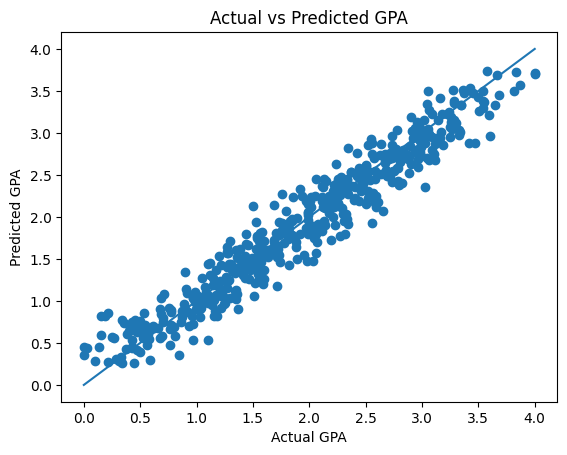

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")
plt.show()


In [ ]:
tolerance = 0.25
acc = np.mean(np.abs(y_pred - y_test) <= tolerance) * 100
print(f"Accuracy within ±{tolerance} GPA:", acc, "%")

Accuracy within ±0.25 GPA: 72.02505219206681 %


In [ ]:
import numpy as np
import pandas as pd

# Your exact feature order
feature_names = ['Ethnicity', 'ParentalEducation', 'Gender', 'StudyTimeWeekly', 'Absences',
                 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music']

def get_int(prompt, allowed=None, min_val=None, max_val=None):
    while True:
        try:
            v = int(input(prompt).strip())
            if allowed is not None and v not in allowed:
                print(f"Invalid. Allowed: {allowed}")
                continue
            if min_val is not None and v < min_val:
                print(f"Invalid. Must be >= {min_val}")
                continue
            if max_val is not None and v > max_val:
                print(f"Invalid. Must be <= {max_val}")
                continue
            return v
        except ValueError:
            print("Invalid input. Enter an integer.")

def get_float(prompt, min_val=None, max_val=None):
    while True:
        try:
            v = float(input(prompt).strip())
            if min_val is not None and v < min_val:
                print(f"Invalid. Must be >= {min_val}")
                continue
            if max_val is not None and v > max_val:
                print(f"Invalid. Must be <= {max_val}")
                continue
            return v
        except ValueError:
            print("Invalid input. Enter a number.")

def predict_gpa_user_input(best_model, scaler):
    print("\nEnter student details using these codes:")
    print("Ethnicity: 0=Caucasian, 1=African American, 2=Asian, 3=Other")
    print("ParentalEducation: 0=None, 1=High School, 2=Some College, 3=Bachelor's, 4=Higher")
    print("Gender: 0=Male, 1=Female")
    print("Tutoring/Extracurricular/Sports/Music: 0=No, 1=Yes")
    print("StudyTimeWeekly: 0 to 20 hours")
    print("Absences: 0 to 30\n")

    user_data = {}
    user_data["Ethnicity"] = get_int("Ethnicity (0-3): ", allowed=[0,1,2,3])
    user_data["ParentalEducation"] = get_int("ParentalEducation (0-4): ", allowed=[0,1,2,3,4])
    user_data["Gender"] = get_int("Gender (0=Male, 1=Female): ", allowed=[0,1])
    user_data["StudyTimeWeekly"] = get_float("StudyTimeWeekly (0-20): ", min_val=0, max_val=20)
    user_data["Absences"] = get_int("Absences (0-30): ", min_val=0, max_val=30)
    user_data["Tutoring"] = get_int("Tutoring (0=No, 1=Yes): ", allowed=[0,1])
    user_data["ParentalSupport"] = get_int("ParentalSupport (0-4): ", allowed=[0,1,2,3,4])
    user_data["Extracurricular"] = get_int("Extracurricular (0=No, 1=Yes): ", allowed=[0,1])
    user_data["Sports"] = get_int("Sports (0=No, 1=Yes): ", allowed=[0,1])
    user_data["Music"] = get_int("Music (0=No, 1=Yes): ", allowed=[0,1])

    # Make 1-row DataFrame in correct order
    user_df = pd.DataFrame([[user_data[f] for f in feature_names]], columns=feature_names)

    # Scale with the SAME scaler used in training
    user_scaled = scaler.transform(user_df)

    # Reshape for CNN+BiGRU: (batch, features, 1)
    user_scaled = user_scaled.reshape(1, user_scaled.shape[1], 1)

    pred = float(best_model.predict(user_scaled, verbose=0).flatten()[0])

    # Optional: clamp to common GPA range
    pred = float(np.clip(pred, 0.0, 4.0))

    print(f"\nPredicted GPA: {pred:.2f}")
    return pred

# Run it
predict_gpa_user_input(best_model, scaler)



Enter student details using these codes:
Ethnicity: 0=Caucasian, 1=African American, 2=Asian, 3=Other
ParentalEducation: 0=None, 1=High School, 2=Some College, 3=Bachelor's, 4=Higher
Gender: 0=Male, 1=Female
Tutoring/Extracurricular/Sports/Music: 0=No, 1=Yes
StudyTimeWeekly: 0 to 20 hours
Absences: 0 to 30



KeyboardInterrupt: Interrupted by user

# Save the best model

In [ ]:
import joblib

# 1. Save the Keras Model
best_model.save('student_gpa_model.keras')

# 2. Save the Scaler (CRITICAL: You need this to transform new inputs exactly like training data)
joblib.dump(scaler, 'minmax_scaler.pkl')

# 3. Download the files to your computer
from google.colab import files
files.download('student_gpa_model.keras')
files.download('minmax_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>